# THOR patch embeddings on openEO

This notebook runs [THOR](https://github.com/FM4CS/THOR), a compute-adaptive Earth observation foundation model, inside an openEO UDF to turn Sentinel-1/2/3 data into a patch embedding cube, then sanity-checks it with PCA and K-means.

See [README.md](./README.md) for architecture details and caveats.

**Steps:**
1. Create the input cube.
2. Run model 1.
3. Run model 2.
4. Compare the outputs.

The embedding cube is a reusable artefact — it can feed a land-cover classifier, change-detection routine, or similarity search, without re-running THOR each time.


## Install and import dependencies

This notebook only needs the openEO client plus the usual scientific-Python stack for
plotting and clustering the *result*. THOR itself (`thor`, `thor_terratorch_ext`,
`terratorch`, `torch`) is only required **offline**, to export the ONNX encoder once
with [`export_thor_to_onnx.py`](./export_thor_to_onnx.py) — the UDF that runs on the
backend only needs `onnxruntime`, which is supplied via a job option, not installed here.

```bash
pip install openeo numpy matplotlib scikit-learn xarray
```


In [50]:
import matplotlib.pyplot as plt
import numpy as np
import openeo
import xarray as xr

## Connect to the backend

Using the [Copernicus Data Space Ecosystem](https://dataspace.copernicus.eu/) openEO endpoint, which hosts Sentinel-1, Sentinel-2 and ESA WorldCover.


In [51]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


## 1. Create the input

A ~10 km AOI on Mount Etna's south flank (Sicily, Italy), summer 2018, processed as a single tile.


In [68]:
CENTER_LAT, CENTER_LON = 37.72, 15.00
HALF_EXTENT_DEG = 0.057   # ~10 km box at this latitude
spatial_extent = {
    "west": CENTER_LON - HALF_EXTENT_DEG,
    "south": CENTER_LAT - HALF_EXTENT_DEG * 0.79,
    "east": CENTER_LON + HALF_EXTENT_DEG,
    "north": CENTER_LAT + HALF_EXTENT_DEG * 0.79,
    "crs": 4326,
}

temporal_extent = ["2018-06-01", "2018-08-31"]
# Used to approximate solar zenith angle for Sentinel-3 reflectance conversion.
ACQUISITION_DATETIME = "2018-07-15T10:30:00"

CLOUD_COVER = 60
S2_BANDS = ["B02", "B03", "B04", "B08"]   # BLUE, GREEN, RED, NIR
S1_BANDS = ["VV", "VH"]
# Band naming varies by backend — verify with connection.describe_collection(...).
S3_OLCI_BANDS = [f"B{i:02d}" for i in range(1, 22)]
S3_SLSTR_REFL_BANDS = [f"S{i}" for i in range(1, 7)]   # 500 m, reflectance
S3_SLSTR_BT_BANDS = [f"S{i}" for i in range(7, 10)]    # 1000 m, brightness temperature

# Common grid resolution (metres) all collections are resampled to before merging.
COMMON_GRID_RESOLUTION = 40


Sentinel-1/2/3 are each temporally reduced to one image (median), converted to the physical units THOR expects, and resampled onto a shared grid (`COMMON_GRID_RESOLUTION`, in metres) before merging into a single cube. Sentinel-2/1 use `bilinear` since 10 m is already their native GSD; Sentinel-3 OLCI/SLSTR use `near` (nearest-neighbour) since they're being *upsampled* from much coarser native pixels (240/480/960 m) — nearest-neighbour block-replicates each native pixel losslessly (exact integer upsampling factors here), instead of `bilinear` permanently blurring/blending native pixels together before anything downstream sees them.

THOR itself doesn't take one combined-resolution grid internally: its real backbone splits the merged tensor back into per-modality channel groups and independently resizes each group to its *own* native-GSD-derived working size (e.g. OLCI always ends up on a 40x40 grid at this `GROUND_COVER`, regardless of `COMMON_GRID_RESOLUTION`) before separately patch-embedding each modality; fusion happens by merging per-modality *token* grids, not by mixing raw pixels. So the shared `COMMON_GRID_RESOLUTION` used here is purely an openEO/ONNX-export convenience (the exported graph takes one combined `(B, C, H, W)` tensor) — it doesn't add real detail for OLCI/SLSTR (their information ceiling is set by their native GSD, not this grid), and matching Sentinel-2's native 10 m is what avoids discarding real Sentinel-1/2 detail before the model sees it.

**Don't lower `COMMON_GRID_RESOLUTION` below 10 m — it can't add real detail (Sentinel-2's own bands are already 10 m native) and it's the main OOM lever.** This example runs the whole AOI as a single `apply_neighborhood` tile (no spatial chunking), and `resample_cube_spatial` still has to materialise 21 OLCI + 9 SLSTR bands onto the common grid *before* the UDF runs, regardless of resample method. Halving `COMMON_GRID_RESOLUTION` roughly quadruples that pre-UDF pixel volume across all 36 bands — that's almost always the actual `OutOfMemoryError`/executor-lost cause, not the ONNX inference itself. If you OOM even with generous `job_options` memory, raise `COMMON_GRID_RESOLUTION` (coarser, sacrificing Sentinel-1/2 detail) rather than lower it, or drop `S3OLCI`/`S3SLSTR_*` for a lighter S1+S2-only profile (see the [README](./README.md)).


In [ ]:
def build_input_cube(extent):
    """Return a THOR-ready cube (S2 BLUE/GREEN/RED/NIR, S1 VV/VH, S3 OLCI/SLSTR) for the AOI."""
    scl = connection.load_collection(
        collection_id="SENTINEL2_L2A",
        spatial_extent=extent,
        temporal_extent=temporal_extent,
        bands=["SCL"],
        properties={"eo:cloud_cover": lambda x: x.lte(CLOUD_COVER)},
    )
    cloud_mask = scl.process(
        "to_scl_dilation_mask",
        data=scl,
        kernel1_size=17,
        kernel2_size=77,
        mask1_values=[2, 4, 5, 6, 7],
        mask2_values=[3, 8, 9, 10, 11],
        erosion_kernel_size=3,
    )
    s2 = (
        connection.load_collection(
            collection_id="SENTINEL2_L2A",
            spatial_extent=extent,
            temporal_extent=temporal_extent,
            bands=S2_BANDS,
            properties={"eo:cloud_cover": lambda x: x.lte(CLOUD_COVER)},
        )
        .mask(cloud_mask)
        .reduce_dimension(dimension="t", reducer="median")
        .apply(lambda x: 0.0001 * x)   # DN -> reflectance [0, 1]
    )
    ref = s2.resample_spatial(resolution=COMMON_GRID_RESOLUTION, method="bilinear")
    s1 = (
        connection.load_collection(
            "SENTINEL1_GRD",
            spatial_extent=extent,
            temporal_extent=temporal_extent,
            bands=S1_BANDS,
        )
        .sar_backscatter(coefficient="sigma0-ellipsoid")
        .reduce_dimension(dimension="t", reducer="median")
        .apply(lambda x: 10.0 * x.log(base=10))   # linear sigma0 -> dB
        .resample_cube_spatial(ref, method="bilinear")
    )
    # Prefixed to avoid band-name collisions once merge_cubes puts everything
    # on one shared "bands" dimension.
    # OLCI/SLSTR are upsampled from a much coarser native GSD to the common
    # grid, so "near" (nearest-neighbour) is used instead of "bilinear" here:
    # since the up-sampling factor is a clean integer (240/480/960 m -> common
    # grid), "near" block-replicates each native pixel losslessly, whereas
    # "bilinear" would permanently blur/blend native pixels together before
    # the UDF (and THOR's own internal per-modality resize) ever see them.
    olci = (
        connection.load_collection(
            "SENTINEL3_OLCI_L1B",
            spatial_extent=extent,
            temporal_extent=temporal_extent,
            bands=S3_OLCI_BANDS,
        )
        .reduce_dimension(dimension="t", reducer="median")
        .rename_labels(dimension="bands", target=[f"OLCI_{b}" for b in S3_OLCI_BANDS])
        .resample_cube_spatial(ref, method="near")
    )
    # SLSTR reflectance (500 m) and brightness-temperature (1000 m) bands have
    # different native resolutions, so they're loaded as separate collections.
    slstr_refl = (
        connection.load_collection(
            "SENTINEL3_SLSTR",
            spatial_extent=extent,
            temporal_extent=temporal_extent,
            bands=S3_SLSTR_REFL_BANDS,
        )
        .reduce_dimension(dimension="t", reducer="median")
        .rename_labels(dimension="bands", target=[f"SLSTR_{b}" for b in S3_SLSTR_REFL_BANDS])
        .resample_cube_spatial(ref, method="near")
    )
    slstr_bt = (
        connection.load_collection(
            "SENTINEL3_SLSTR",
            spatial_extent=extent,
            temporal_extent=temporal_extent,
            bands=S3_SLSTR_BT_BANDS,
        )
        .reduce_dimension(dimension="t", reducer="median")
        .rename_labels(dimension="bands", target=[f"SLSTR_{b}" for b in S3_SLSTR_BT_BANDS])
        .resample_cube_spatial(ref, method="near")
    )
    return ref.merge_cubes(s1).merge_cubes(olci).merge_cubes(slstr_refl).merge_cubes(slstr_bt)


merged = build_input_cube(spatial_extent)


(np.float64(-0.5), np.float64(1005.5), np.float64(999.5), np.float64(-0.5))

(np.float64(-0.5), np.float64(1005.5), np.float64(999.5), np.float64(-0.5))

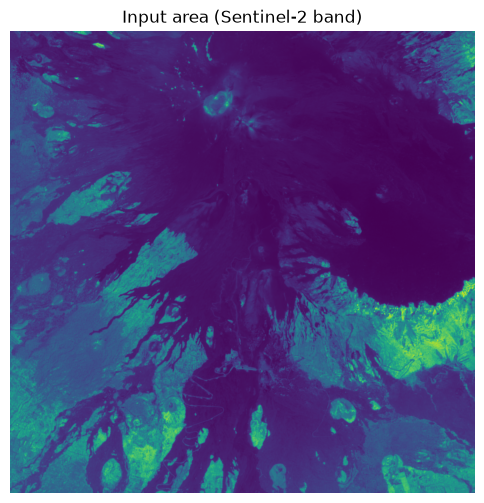

In [54]:
input_ds = xr.open_dataset("results/thor_input.nc")
if "crs" in input_ds.variables:
    input_ds = input_ds.drop_vars("crs")

input_arr = input_ds.to_array(dim="bands").squeeze()   # (bands, y, x)

plt.figure(figsize=(6, 6))
plt.imshow(input_arr[3])   # B04 (RED)
plt.title("Input area (Sentinel-2 band)")
plt.axis("off")


## 2. Run model 1

THOR is compute-adaptive: instead of one fixed input resolution, it's exported with a chosen `patch_size` per sensor, which sets how fine-grained the output embedding grid is. We ship two pre-exported models to compare:

| Model   | Output grid | Detail      |
|---------|-------------|-------------|
| model 1 | 30×30       | standard    |
| model 2 | 60×60       | ~4× finer   |

No PyTorch needed here — THOR was already exported to ONNX offline (see [`export_thor_to_onnx.py`](./export_thor_to_onnx.py)); the UDF only needs `onnxruntime` at runtime.


In [70]:
embedding_udf_1 = openeo.UDF.from_file(
    "udf_thor_embedding.py",
    context={
        "onnx_dir": "thor_v1_base_onnx",
        "onnx_filename": "thor_v1_base_encoder.onnx",
        "bands_json": "bands_order.json",
        "center_lat": CENTER_LAT,
        "center_lon": CENTER_LON,
        "acquisition_datetime": ACQUISITION_DATETIME,
    },
)

# apply_neighborhood's size == the full AOI extent, i.e. this runs as a single
# tile with no spatial chunking, so overlap doesn't apply here (there's no
# neighboring tile to overlap with) — only meaningful once you tile a bigger AOI.
tile_px = 9600 // COMMON_GRID_RESOLUTION   # AOI matches the model's ground cover exactly
embedding_cube_1 = merged.apply_neighborhood(
    process=embedding_udf_1,
    size=[
        {"dimension": "x", "value": tile_px, "unit": "px"},
        {"dimension": "y", "value": tile_px, "unit": "px"},
    ],
    overlap=[
        {"dimension": "x", "value": 0, "unit": "px"},
        {"dimension": "y", "value": 0, "unit": "px"},
    ],
)

# The OOMs come from resample_cube_spatial upsampling 21 OLCI + 9 SLSTR bands
# (native 300-1200 m) onto the fine common grid before the UDF even runs — not
# from the UDF itself. Raising memory further is a stopgap, not a fix; see the
# markdown above for why COMMON_GRID_RESOLUTION is the real lever.
job_options = {
    "driver-memory": "4g",
    "executor-memory": "8g",
    "executor-memoryOverhead": "8g",
    "python-memory": "disable",
    "executor-cores": 1,
    "udf-dependency-archives": [
        "https://s3.waw3-1.cloudferro.com/project_dependencies/onnx_deps_python311.zip#onnx_deps",
        "https://s3.waw3-1.cloudferro.com/project_dependencies/thor_embedding/thor_v1_base_gc9600_ps32-32-8-4-2.zip#thor_v1_base_onnx",
    ],
}

embedding_paths = {}
embedding_paths["model_1"] = "results/thor_embedding_model_1.nc"
embedding_cube_1.save_result(format="NetCDF").execute_batch(
    embedding_paths["model_1"],
    title="THOR embedding (model_1)",
    job_options=job_options,
)
print(embedding_paths)


0:00:00 Job 'j-26092514023845e582b40b8f3895e1e8': send 'start'
0:00:03 Job 'j-26092514023845e582b40b8f3895e1e8': queued (progress 0%)
0:00:09 Job 'j-26092514023845e582b40b8f3895e1e8': queued (progress 0%)
0:00:15 Job 'j-26092514023845e582b40b8f3895e1e8': queued (progress 0%)
0:00:23 Job 'j-26092514023845e582b40b8f3895e1e8': queued (progress 0%)
0:00:33 Job 'j-26092514023845e582b40b8f3895e1e8': queued (progress 0%)
0:00:45 Job 'j-26092514023845e582b40b8f3895e1e8': queued (progress 0%)
0:01:01 Job 'j-26092514023845e582b40b8f3895e1e8': queued (progress 0%)
0:01:20 Job 'j-26092514023845e582b40b8f3895e1e8': queued (progress 0%)
0:01:44 Job 'j-26092514023845e582b40b8f3895e1e8': queued (progress 0%)
0:02:14 Job 'j-26092514023845e582b40b8f3895e1e8': running (progress N/A)
0:02:52 Job 'j-26092514023845e582b40b8f3895e1e8': running (progress N/A)
0:03:39 Job 'j-26092514023845e582b40b8f3895e1e8': running (progress N/A)
0:04:37 Job 'j-26092514023845e582b40b8f3895e1e8': running (progress N/A)
0:05:3

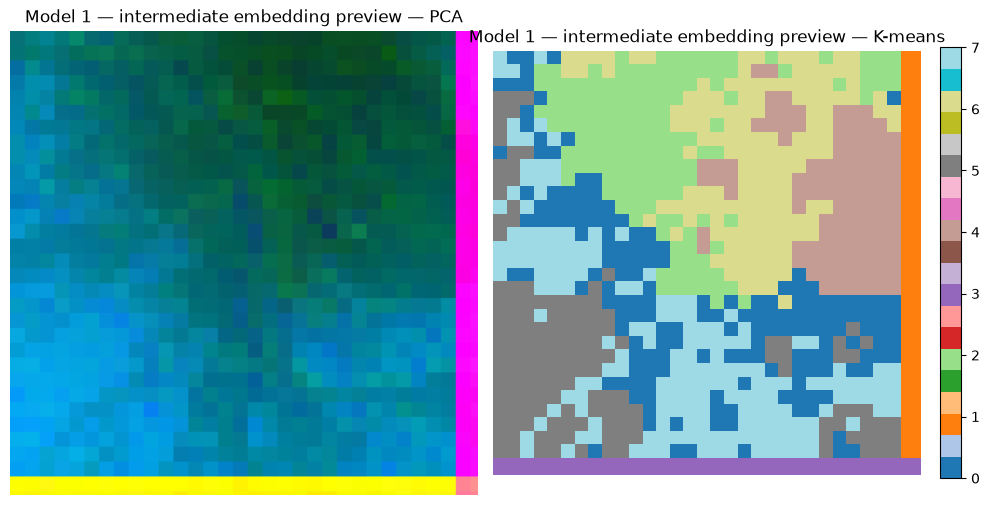

In [71]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


def preview_embedding(result, title, n_clusters=8):
    ds = result if hasattr(result, "to_array") else xr.open_dataset(result)
    if "crs" in ds.variables:
        ds = ds.drop_vars("crs")
    arr = ds.to_array(dim="bands").squeeze()
    flat = arr.values.reshape(arr.shape[0], -1).T

    rgb = PCA(n_components=3).fit_transform(flat).reshape(arr.shape[1], arr.shape[2], 3)
    lo, hi = np.percentile(rgb, [2, 98], axis=(0, 1))
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-8), 0, 1)

    labels = KMeans(n_clusters=n_clusters, n_init=10, random_state=0).fit_predict(flat)
    label_map = labels.reshape(arr.shape[1], arr.shape[2])

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(rgb)
    axes[0].set_title(f"{title} — PCA")
    axes[0].axis("off")

    im = axes[1].imshow(label_map, cmap="tab20", interpolation="nearest",
                        vmin=0, vmax=max(n_clusters - 1, 1))
    axes[1].set_title(f"{title} — K-means")
    axes[1].axis("off")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    fig.tight_layout()
    plt.show()


preview_embedding(xr.open_dataset(embedding_paths["model_1"]), "Model 1 — intermediate embedding preview")


In [ ]:
embedding_udf_2 = openeo.UDF.from_file(
    "udf_thor_embedding.py",
    context={
        "onnx_dir": "thor_v1_base_onnx",
        "onnx_filename": "thor_v1_base_encoder.onnx",
        "bands_json": "bands_order.json",
        "center_lat": CENTER_LAT,
        "center_lon": CENTER_LON,
        "acquisition_datetime": ACQUISITION_DATETIME,
    },
)

embedding_cube_2 = merged.apply_neighborhood(
    process=embedding_udf_2,
    size=[
        {"dimension": "x", "value": tile_px, "unit": "px"},
        {"dimension": "y", "value": tile_px, "unit": "px"},
    ],
    overlap=[
        {"dimension": "x", "value": 0, "unit": "px"},
        {"dimension": "y", "value": 0, "unit": "px"},
    ],
)

job_options = {
    "driver-memory": "8g",
    "executor-memory": "16g",
    "executor-memoryOverhead": "16g",
    "python-memory": "disable",
    "executor-cores": 1,
    "udf-dependency-archives": [
        "https://s3.waw3-1.cloudferro.com/project_dependencies/onnx_deps_python311.zip#onnx_deps",
        "https://s3.waw3-1.cloudferro.com/project_dependencies/thor_embedding/thor_v1_base_gc9600_ps16-16-4-2-2.zip#thor_v1_base_onnx",
    ],
}

embedding_paths["model_2"] = "results/thor_embedding_model_2.nc"
embedding_cube_2.save_result(format="NetCDF").execute_batch(
    embedding_paths["model_2"],
    title="THOR embedding (model_2)",
    job_options=job_options,
)
preview_embedding(xr.open_dataset(embedding_paths["model_2"]), "Model 2 — intermediate embedding preview")
print(embedding_paths)


## 4. Compare the outputs

Project each embedding down to 3 components with PCA and render as a false-colour composite. Model 2 should look visibly sharper than model 1.


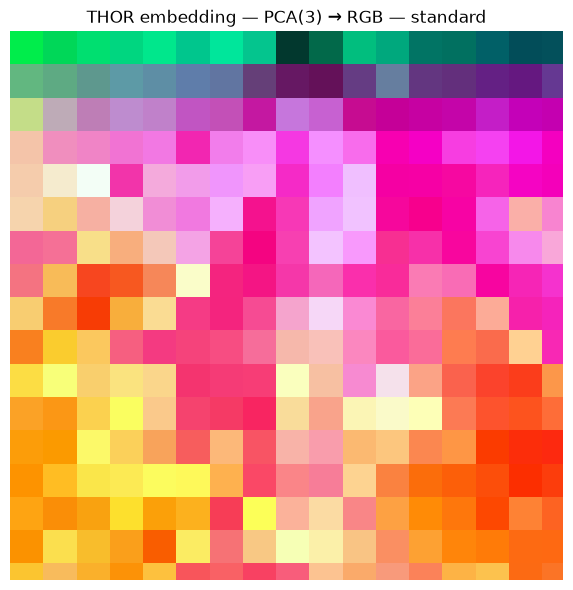

In [40]:
from sklearn.decomposition import PCA


def pca_rgb(emb_arr):
    """Project a (bands, y, x) embedding down to a (y, x, 3) RGB preview via PCA."""
    n_bands, H, W = emb_arr.shape
    flat = emb_arr.values.reshape(n_bands, -1).T   # (pixels, D)
    rgb = PCA(n_components=3).fit_transform(flat).reshape(H, W, 3)
    lo, hi = np.percentile(rgb, [2, 98], axis=(0, 1))
    return np.clip((rgb - lo) / (hi - lo + 1e-8), 0, 1), flat


emb_arrays = {}
flats = {}
rgb_previews = {}
for key, path in embedding_paths.items():
    ds = xr.open_dataset(path)
    if "crs" in ds.variables:
        ds = ds.drop_vars("crs")
    arr = ds.to_array(dim="bands").squeeze()
    emb_arrays[key] = arr
    rgb_previews[key], flats[key] = pca_rgb(arr)

fig, axes = plt.subplots(1, len(rgb_previews), figsize=(6 * len(rgb_previews), 6))
if len(rgb_previews) == 1:
    axes = [axes]
for ax, (key, rgb) in zip(axes, rgb_previews.items()):
    ax.imshow(rgb)
    ax.set_title(f"THOR embedding — PCA(3) → RGB — {key}")
    ax.axis("off")
plt.tight_layout()

# Keep the model 2 arrays around for the K-means cell + downstream export.
rgb_pca = rgb_previews.get("model_2", next(iter(rgb_previews.values())))
flat = flats.get("model_2", next(iter(flats.values())))
emb_arr = emb_arrays.get("model_2", next(iter(emb_arrays.values())))
n_bands, H, W = emb_arr.shape


## Downstream example: unsupervised clustering (K-means)

Cluster each embedding with K-means and colour pixels by cluster label, as a quick sanity check that the embeddings capture real land-cover structure.


In [ ]:
from sklearn.cluster import KMeans

n_clusters = 8

label_maps = {}
for key, arr in emb_arrays.items():
    Hk, Wk = arr.shape[1], arr.shape[2]
    flat_k = arr.values.reshape(arr.shape[0], -1).T
    labels_k = KMeans(n_clusters=n_clusters, n_init=10, random_state=0).fit_predict(flat_k)
    label_maps[key] = labels_k.reshape(Hk, Wk)

# S2 RGB reference from the input cube.
rgb = np.stack(
    [input_arr[2].values, input_arr[1].values, input_arr[0].values], axis=-1
)
rgb = np.clip(rgb / 3000.0, 0, 1)

n_cols = 1 + 2 * len(label_maps)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
axes[0].imshow(rgb)
axes[0].set_title("Sentinel-2 RGB")
axes[0].axis("off")

col = 1
for key, label_map in label_maps.items():
    im = axes[col].imshow(label_map, cmap="tab20", interpolation="nearest",
                          vmin=0, vmax=max(n_clusters - 1, 1))
    axes[col].set_title(f"K-means (k={n_clusters}) — {key}")
    axes[col].axis("off")
    fig.colorbar(im, ax=axes[col], fraction=0.046, pad=0.04)

    axes[col + 1].imshow(rgb)
    axes[col + 1].imshow(label_map, cmap="tab20",
                         interpolation="nearest", vmin=0, vmax=max(n_clusters - 1, 1),
                         alpha=0.55,
                         extent=(0, rgb.shape[1], rgb.shape[0], 0))
    axes[col + 1].set_title(f"S2 RGB + overlay — {key}")
    axes[col + 1].axis("off")
    col += 2

plt.tight_layout()

# Keep the model 2 map around for the export cell below.
label_map = label_maps.get("model_2", next(iter(label_maps.values())))


## Export results

The embedding cube was already materialised as `results/thor_embedding.nc` (NetCDF) by
the batch job above — that's the reusable artefact other notebooks/pipelines should
consume. Here we additionally save the PCA-RGB preview and the K-means cluster map as
plain NumPy arrays / GeoTIFF-less PNGs for quick sharing.


In [ ]:
import os

os.makedirs("results", exist_ok=True)

np.save("results/thor_pca_rgb.npy", rgb_pca)
np.save("results/thor_kmeans_labels.npy", label_map)
plt.imsave("results/thor_pca_rgb.png", rgb_pca)

print("Saved:")
print(" - results/thor_embedding.nc      (full embedding cube, NetCDF)")
print(" - results/thor_pca_rgb.npy/.png  (PCA(3) preview)")
print(" - results/thor_kmeans_labels.npy (unsupervised cluster labels)")


## Conclusion

We ran the pretrained THOR backbone as an ONNX model inside an openEO UDF (no PyTorch in the sandbox — just `onnxruntime`) to produce a patch embedding cube from Sentinel-1/2/3, and sanity-checked it with PCA and K-means.

### Where to go next

- Try a different THOR size (`thor_v1_tiny`/`small`/`large`) in [`export_thor_to_onnx.py`](./export_thor_to_onnx.py).
- Drop Sentinel-3 for a lighter S1+S2-only example.
- Feed the embedding cube into a downstream classifier, e.g. via `fit_class_random_forest` — see [`../../40_machine-learning/dynamic-land-cover-mapping`](../../40_machine-learning/dynamic-land-cover-mapping).
